# Day 5 - Full Code

## 1. Imports

In [185]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## 2. Load the Dataset

In [186]:
df = pd.read_csv("dataset/titanic/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Select Features and Target

In [187]:
X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
].copy()

y = df["Survived"]

## 4. Split the Data

In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

## 5. Handle Missing Values

### Age

In [189]:
age_median = X_train["Age"].median()

X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"] = X_test["Age"].fillna(age_median)

### Embarked

In [190]:
embarked_mode = X_train["Embarked"].mode()[0]

X_train["Embarked"] = X_train["Embarked"].fillna(embarked_mode)
X_test["Embarked"] = X_test["Embarked"].fillna(embarked_mode)

## 6. One-Hot Encode Categorical Features

In [191]:
X_train = pd.get_dummies(
    X_train,
    columns = ["Sex", "Embarked"],
    drop_first = True
)

X_test = pd.get_dummies(
    X_test,
    columns = ["Sex", "Embarked"],
    drop_first = True
)

Make sure both datasets have exactly the same columns:

In [192]:
X_test = X_test.reindex(
    columns = X_train.columns,
    fill_value = 0
)

## 7. Check the Final Data

In [193]:
print("Training Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nMissing values in training:")
print(X_train.isnull().sum())

print("\nMissing values in test:")
print(X_test.isnull().sum())

Training Shape: (712, 8)
Test Shape: (179, 8)

Missing values in training:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Missing values in test:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [194]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("dataset/titanic/train.csv")

df.head()


X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
].copy()

y = df["Survived"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)


age_median = X_train["Age"].median()

X_train["Age"] = X_train["Age"].fillna(age_median)
X_test["Age"] = X_test["Age"].fillna(age_median)


embarked_mode = X_train["Embarked"].mode()[0]

X_train["Embarked"] = X_train["Embarked"].fillna(embarked_mode)
X_test["Embarked"] = X_test["Embarked"].fillna(embarked_mode)


X_train = pd.get_dummies(
    X_train,
    columns = ["Sex", "Embarked"],
    drop_first = True
)

X_test = pd.get_dummies(
    X_test,
    columns = ["Sex", "Embarked"],
    drop_first = True
)


print("Training Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print("\nMissing Values in training:")
print(X_train.isnull().sum().sum())

print("\nMissing Values in Test:")
print(X_test.isnull().sum().sum())



Training Shape: (712, 8)
Test Shape: (179, 8)

Missing Values in training:
0

Missing Values in Test:
0


## 8. Your First Experiment — Very Deep Tree

In [195]:
deep_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

deep_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 9. Evaluate Training and Test Accuracy

In [196]:
train_pred = deep_model.predict(X_train)
test_pred = deep_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9831460674157303
Test Accuracy: 0.8268156424581006


Now calculate the overfitting gap:

In [197]:
overfitting_gap = train_accuracy - test_accuracy

print("Overfitting Gap:", overfitting_gap)

Overfitting Gap: 0.15633042495762972


And inspect the tree:

In [198]:
print("Tree Depth:", deep_model.get_depth())
print("Number of Leaves:", deep_model.get_n_leaves())

Tree Depth: 23
Number of Leaves: 154


## 10. Control the Tree Depth

In [199]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, None]

Create a result list:

In [200]:
depth_results = []

Run every depth:

In [201]:
for depth in depths:
    model = DecisionTreeClassifier(
        max_depth = depth,
        random_state = 42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    depth_results.append({
        "max_depth":depth,
        "training_accuracy":train_accuracy,
        "test_accuracy": test_accuracy,
        "overfitting_gap": train_accuracy-test_accuracy,
        "tree_depth":model.get_depth(),
        "number_of_leaves":model.get_n_leaves()
    })

Convert the results into a DataFrame:

In [202]:
depth_results_df = pd.DataFrame(depth_results)

depth_results_df

,max_depth,training_accuracy,test_accuracy,overfitting_gap,tree_depth,number_of_leaves
0,1.0,0.789326,0.776536,0.012790,1,2
1,2.0,0.804775,0.759777,0.044999,2,4
2,3.0,0.832865,0.793296,0.039569,3,8
3,4.0,0.841292,0.787709,0.053583,4,15
4,5.0,0.865169,0.765363,0.099805,5,23
5,7.0,0.891854,0.804469,0.087385,7,48
6,10.0,0.945225,0.804469,0.140755,10,89
7,15.0,0.963483,0.832402,0.131081,15,113
8,NaN,0.983146,0.826816,0.156330,23,154


## 11. Plot Training vs Test Accuracy
Because None cannot be directly plotted as a numeric depth, create a plotting column.

In [203]:
plot_df = depth_results_df.copy()

plot_df["depth_for_plot"] = plot_df["max_depth"].fillna(
    plot_df["tree_depth"]
)

Now plot:

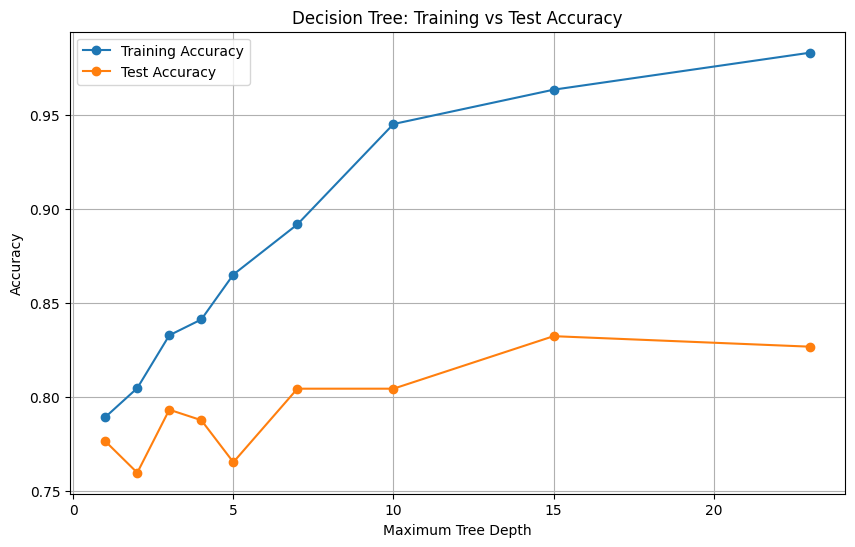

In [204]:
plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["depth_for_plot"],
    plot_df["training_accuracy"],
    marker = "o",
    label = "Training Accuracy"
)

plt.plot(
    plot_df["depth_for_plot"],
    plot_df["test_accuracy"],
    marker = "o",
    label = "Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Test Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## 12. Model A — Almost Unrestricted

In [205]:
model_a = DecisionTreeClassifier(
    max_depth = None,
    random_state = 42
)

model_a.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Evaluate:

In [206]:
model_a_train_pred = model_a.predict(X_train)
model_a_test_pred = model_a.predict(X_test)

model_a_train_accuracy = accuracy_score(y_train, model_a_train_pred)
model_a_test_accuracy = accuracy_score(y_test, model_a_test_pred)

## 13. Model B — Controlled Depth

In [207]:
model_b = DecisionTreeClassifier(
    max_depth = 5,
    random_state = 42
)

model_b.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Evaluate:

In [208]:
model_b_train_pred = model_b.predict(X_train)
model_b_test_pred = model_b.predict(X_test)

model_b_train_accuracy = accuracy_score(
    y_train,
    model_b_train_pred
)

model_b_test_accuracy = accuracy_score(
    y_test,
    model_b_test_pred
)

## 14. Model C — More Regularization

In [209]:
model_c = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_c.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Evaluate:

In [210]:
model_c_train_pred = model_c.predict(X_train)
model_c_test_pred = model_c.predict(X_test)

model_c_train_accuracy = accuracy_score(
    y_train,
    model_c_train_pred
)

model_c_test_accuracy = accuracy_score(
    y_test,
    model_c_test_pred
)

## 15. Compare Model A, B and C

In [211]:
comparison = pd.DataFrame({
    "Model": [
        "Model A - Unrestricted",
        "Model B - max_depth=5",
        "Model C - Regularized"
    ],

    "Training Accuracy": [
        model_a_train_accuracy,
        model_b_train_accuracy,
        model_c_train_accuracy
    ],

    "Test Accuracy": [
        model_a_test_accuracy,
        model_b_test_accuracy,
        model_c_test_accuracy
    ],

    "Tree Depth": [
        model_a.get_depth(),
        model_b.get_depth(),
        model_c.get_depth()
    ],

    "Number of Leaves": [
        model_a.get_n_leaves(),
        model_b.get_n_leaves(),
        model_c.get_n_leaves()
    ],

    "Overfitting Gap": [
        model_a_train_accuracy - model_a_test_accuracy,
        model_b_train_accuracy - model_b_test_accuracy,
        model_c_train_accuracy - model_c_test_accuracy
    ]
})

comparison

,Model,Training Accuracy,Test Accuracy,Tree Depth,Number of Leaves,Overfitting Gap
0,Model A - Unrestricted,0.983146,0.826816,23,154,0.156330
1,Model B - max_depth=5,0.865169,0.765363,5,23,0.099805
2,Model C - Regularized,0.858146,0.770950,5,23,0.087196


## 16. Make the Comparison Easier to Read

In [212]:
comparison.round(4)

,Model,Training Accuracy,Test Accuracy,Tree Depth,Number of Leaves,Overfitting Gap
0,Model A - Unrestricted,0.9831,0.8268,23,154,0.1563
1,Model B - max_depth=5,0.8652,0.7654,5,23,0.0998
2,Model C - Regularized,0.8581,0.7709,5,23,0.0872


You can also sort by test accuracy for analysis, but don't treat this as a universal "best model" rule:

In [213]:
comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Training Accuracy,Test Accuracy,Tree Depth,Number of Leaves,Overfitting Gap
0,Model A - Unrestricted,0.983146,0.826816,23,154,0.156330
2,Model C - Regularized,0.858146,0.770950,5,23,0.087196
1,Model B - max_depth=5,0.865169,0.765363,5,23,0.099805


## 17. Visualize the Three Models

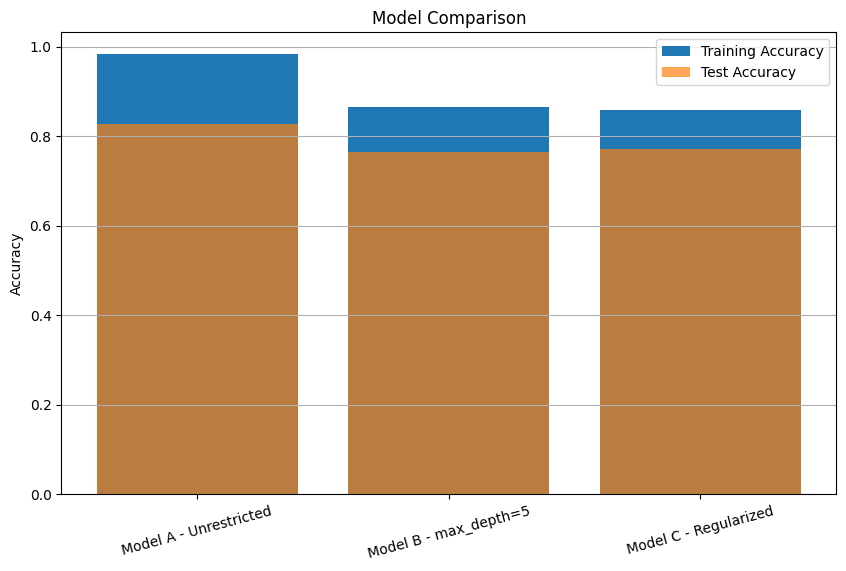

In [214]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["Training Accuracy"],
    label="Training Accuracy"
)

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"],
    alpha=0.7,
    label="Test Accuracy"
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis="y")

plt.show()

## 18. Final Experiment Summary

In [217]:
print("===== DAY 5 EXPERIMENT SUMMARY =====")

print("\nModel A - Almost Unrestricted")
print("Training Accuracy:", round(model_a_train_accuracy, 4))
print("Test Accuracy:", round(model_a_test_accuracy, 4))
print("Tree Depth:", model_a.get_depth())
print("Leaves:", model_a.get_n_leaves())

print("\nModel B - Controlled Depth")
print("Training Accuracy:", round(model_b_train_accuracy, 4))
print("Test Accuracy:", round(model_b_test_accuracy, 4))
print("Tree Depth:", model_b.get_depth())
print("Leaves:", model_b.get_n_leaves())

print("\nModel C - More Regularization")
print("Training Accuracy:", round(model_c_train_accuracy, 4))
print("Test Accuracy:", round(model_c_test_accuracy, 4))
print("Tree Depth:", model_c.get_depth())
print("Leaves:", model_c.get_n_leaves())

===== DAY 5 EXPERIMENT SUMMARY =====

Model A - Almost Unrestricted
Training Accuracy: 0.9831
Test Accuracy: 0.8268
Tree Depth: 23
Leaves: 154

Model B - Controlled Depth
Training Accuracy: 0.8652
Test Accuracy: 0.7654
Tree Depth: 5
Leaves: 23

Model C - More Regularization
Training Accuracy: 0.8581
Test Accuracy: 0.7709
Tree Depth: 5
Leaves: 23
